# Validação da máscara de restrições

## Imports

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from dotenv import find_dotenv, load_dotenv
import os

## PATHS

In [2]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)

project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
    print(f"Credenciais carregadas com sucesso de: {KEY_PATH_ABSOLUTE}")
else:
    print(
        "Aviso: A variável GOOGLE_APPLICATION_CREDENTIALS não foi encontrada no arquivo .env"
    )
    print("O acesso ao GCS pode falhar.")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")

STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
MASK_PATH = f"gs://{BUCKET_NAME}/processed/mascara_exclusao_final.gpkg"
SUPER_LAYER_PATH = (
    f"gs://{BUCKET_NAME}/processed/restricoes_consolidadas_com_atributos.gpkg"
)

Credenciais carregadas com sucesso de: g:\BackupC\Faculdade\UFRJ\TCC\analise-geografica-energia-solar-brasil\.secrets/tcc-usinas-solares-brasil-29b2750a20f8.json


## Carga de Dados

In [3]:
states_gdf = gpd.read_file(STATES_PATH)
mascara_gdf = gpd.read_file(MASK_PATH)
super_camada_gdf = gpd.read_file(SUPER_LAYER_PATH)
print("Máscaras de exclusão e limites dos estados carregados com sucesso!")

Máscaras de exclusão e limites dos estados carregados com sucesso!


## Inspeção da máscara única

In [4]:
print(f"\nSistema de Coordenadas (CRS) da máscara: {mascara_gdf.crs}")
print(f"Quantidade de geometrias na máscara: {len(mascara_gdf)}")


Sistema de Coordenadas (CRS) da máscara: EPSG:4674
Quantidade de geometrias na máscara: 1


## Mapa de restrição da máscara única


Gerando mapa consolidado final das áreas de restrição...


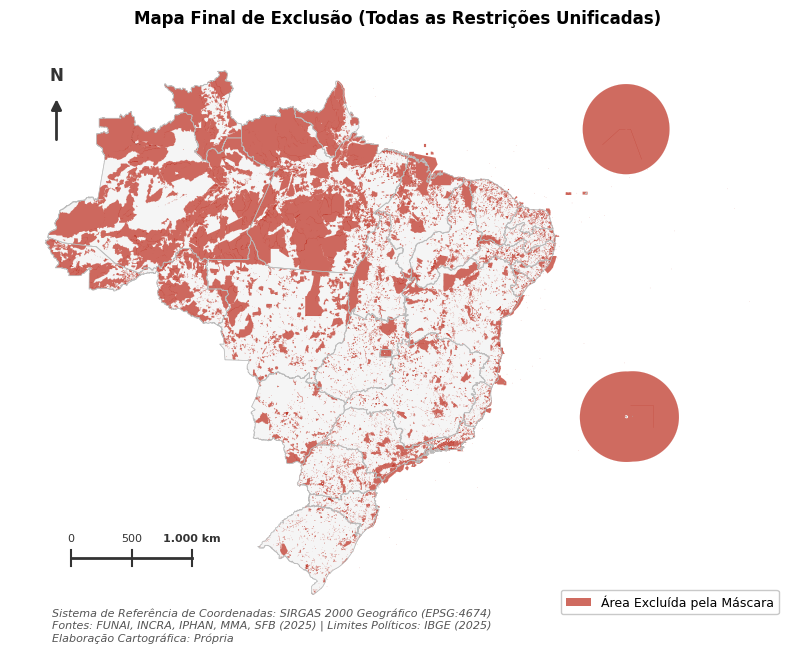

In [5]:
# Configuração de fontes para garantir textos reais pesquisáveis no PDF vetorial
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

print("\nGerando mapa consolidado final das áreas de restrição...")
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. Fundo do Brasil (Preenchimento cinza sutil e linhas de limite de estados discretas)
states_gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#dcdcdc", linewidth=0.5, zorder=1)

# 2. Plotagem da máscara de exclusão unificada
# O uso de rasterized=True é fundamental para que o preenchimento complexo da máscara 
# de exclusão não infle o tamanho do PDF final de dezenas de megabytes para o LaTeX.
mascara_gdf.plot(
    ax=ax, 
    color="#c0392b",     # Vermelho escuro clássico técnico de cartografia de restrições
    alpha=0.75, 
    edgecolor="face",    # Sela quaisquer bordas de anti-aliasing nos visualizadores de PDF
    linewidth=0.1,
    rasterized=True,     # Mantém o raster das restrições leve sem perder vetorização de textos
    zorder=2
)

# 3. Sobreposição de limites estaduais mais fortes para contexto de fundo do Brasil
states_gdf.plot(ax=ax, color="none", edgecolor="#bcbcbc", linewidth=0.5, zorder=3)

# ==============================================================================
# ELEMENTOS CARTOGRÁFICOS RÍGIDOS (SIRGAS 2000, Decreto nº 89.817)
# ==============================================================================

# A. Indicador de Norte Minimalista (Seta limpa sem cauda)
# Afastado para a esquerda (x=0.06) para não interferir na divisa do Acre/Amazonas
ax.annotate('', xy=(0.06, 0.91), xytext=(0.06, 0.83),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle="-|>", color="#333333", lw=2.0, mutation_scale=15),
            ha='center', va='center')
ax.text(0.06, 0.93, 'N', transform=ax.transAxes, ha='center', va='bottom', 
        fontsize=12, weight='bold', color='#333333')

# B. Escala Gráfica de 1.000 km 
# Calculada para a latitude média do Brasil (15° S) no sistema EPSG:4674 (SIRGAS 2000)
# Onde 1 grau de longitude equivale a aproximadamente 107.5 km. 1.000 km ≈ 9.3 graus.
scale_x_start = -72.0
scale_x_mid = -67.35
scale_x_end = -62.70
scale_y = -31.0

# Desenha a linha da escala e seus respectivos ticks (marcações de limite)
ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y], color='#333333', linewidth=2.0)
ax.plot([scale_x_start, scale_x_start], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)
ax.plot([scale_x_mid, scale_x_mid], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)
ax.plot([scale_x_end, scale_x_end], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)

# Rótulos numéricos da escala gráfica
ax.text(scale_x_start, scale_y + 1.2, '0', ha='center', fontsize=8, color='#333333')
ax.text(scale_x_mid, scale_y + 1.2, '500', ha='center', fontsize=8, color='#333333')
ax.text(scale_x_end, scale_y + 1.2, '1.000 km', ha='center', fontsize=8, color='#333333', weight='bold')

# C. Metadados de Projeção, Datum, Escala Numérica e Classe (Decreto nº 89.817)
metadata_text = (
    "Sistema de Referência de Coordenadas: SIRGAS 2000 Geográfico (EPSG:4674)\n"
    "Fontes: FUNAI, INCRA, IPHAN, MMA, SFB (2025) | Limites Políticos: IBGE (2025)\n"
    "Elaboração Cartográfica: Própria"
)
ax.text(-73.5, -34.8, metadata_text, fontsize=8, style='italic', color='#555555', ha='left', va='top')

# ==============================================================================

# Customização da Legenda com moldura protetora elegante
legend_elements = [
    Patch(facecolor="#c0392b", alpha=0.75, label="Área Excluída pela Máscara")
]
ax.legend(
    handles=legend_elements, 
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#bcbcbc",
    fancybox=True,
    fontsize=9
)

ax.set_title("Mapa Final de Exclusão (Todas as Restrições Unificadas)", fontsize=12, pad=15, weight='bold')
ax.set_axis_off()

# 4. Salva a figura em formato PDF vetorial leve e de altíssima nitidez
plt.savefig("../results/figures/mascara_restricao_brasil.pdf", format="pdf", bbox_inches="tight")
plt.savefig("../results/figures/mascara_restricao_brasil.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

## Inspeção da máscra com informação de tipo

In [6]:
print("\n--- Análise da Camada com tipos ---")
print(f"CRS: {super_camada_gdf.crs}")
print(f"Total de polígonos de restrição: {len(super_camada_gdf)}")

print("\nContagem de polígonos por origem:")
print(super_camada_gdf["origem"].value_counts())


--- Análise da Camada com tipos ---
CRS: EPSG:4674
Total de polígonos de restrição: 42468

Contagem de polígonos por origem:
origem
Sitio Arqueologico        30056
Assentamento Rural         8220
Unidade de Conservacao     3122
Terra Indigena              638
Territorio Quilombola       432
Name: count, dtype: int64


## Mapa de Restrição com informação de tipo


Gerando mapa da Camada com informação de tipo de restrição...


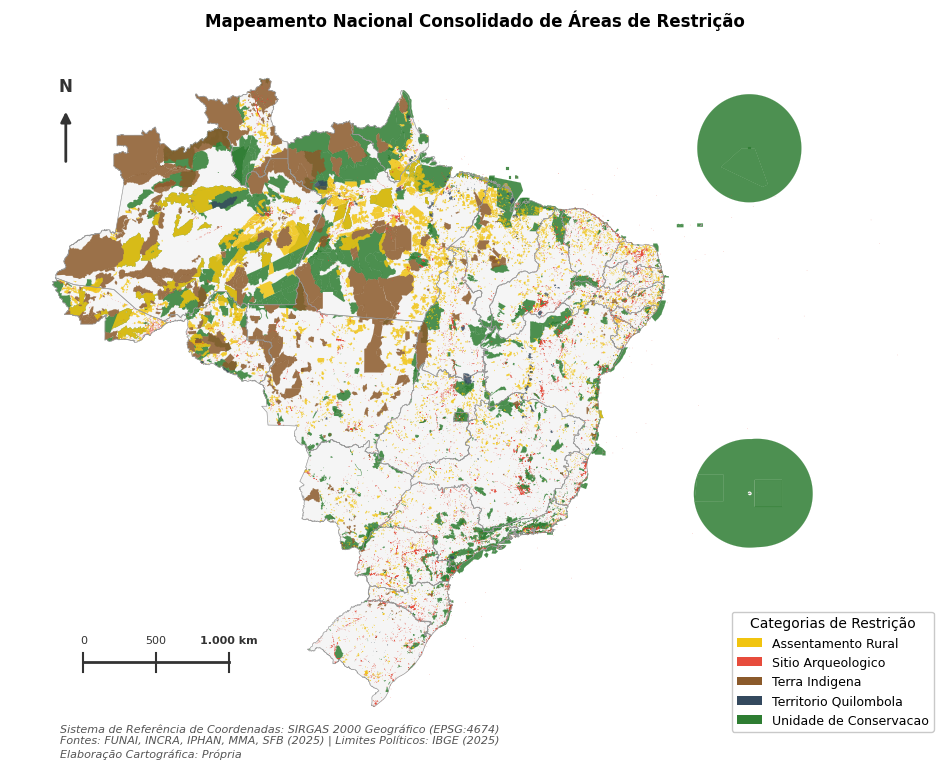

In [9]:
# Configuração de fontes para garantir textos reais pesquisáveis no PDF vetorial
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

print("\nGerando mapa da Camada com informação de tipo de restrição...")
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 1. Fundo do Brasil (Preenchimento cinza neutro e linhas de limite de estados discretas)
states_gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#dcdcdc", linewidth=0.5, zorder=1)

# Paleta de cores premium adaptada para cartografia acadêmica (substituindo cores primárias)
cores = {
    "Assentamento Rural": "#f1c40f",       # Amarelo queimado técnico
    "Sitio Arqueologico": "#e74c3c",       # Vermelho coral
    "Terra Indigena": "#8b5a2b",           # Marrom sienna discreto
    "Territorio Quilombola": "#34495e",    # Cinza ardósia / chumbo
    "Unidade de Conservacao": "#2e7d32",   # Verde floresta médio
}

super_camada_gdf["cor"] = super_camada_gdf["origem"].map(cores)

# 2. Plotagem das camadas de restrição utilizando o buffer de prevenção e fusão de bordas
# O parâmetro rasterized=True é crítico aqui, pois a malha de restrição nacional consolidada
# possui milhões de vértices. Isso evita PDFs pesados de centenas de megabytes.
super_camada_gdf.plot(
    ax=ax,
    color=super_camada_gdf["cor"],
    alpha=0.85,
    edgecolor="face",   # Elimina linhas pretas ou wireframes indesejados nas junções
    linewidth=0.1,
    rasterized=True,
    zorder=2
)

# 3. Sobreposição das divisas estaduais sobre as restrições para manter o contexto territorial
states_gdf.plot(ax=ax, color="none", edgecolor="#999999", linewidth=0.4, zorder=3)

# ==============================================================================
# ELEMENTOS CARTOGRÁFICOS RÍGIDOS (SIRGAS 2000, Decreto nº 89.817)
# ==============================================================================

# A. Indicador de Norte Minimalista (Seta limpa sem cauda)
# Afastado para a esquerda (x=0.06) para não interferir na divisa do Acre/Amazonas
ax.annotate('', xy=(0.06, 0.91), xytext=(0.06, 0.83),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle="-|>", color="#333333", lw=2.0, mutation_scale=15),
            ha='center', va='center')
ax.text(0.06, 0.93, 'N', transform=ax.transAxes, ha='center', va='bottom', 
        fontsize=12, weight='bold', color='#333333')

# B. Escala Gráfica de 1.000 km 
# Calculada para a latitude média do Brasil (15° S) no sistema EPSG:4674 (SIRGAS 2000)
# Onde 1 grau de longitude equivale a aproximadamente 107.5 km. 1.000 km ≈ 9.3 graus.
scale_x_start = -72.0
scale_x_mid = -67.35
scale_x_end = -62.70
scale_y = -31.0

# Desenha a linha da escala e seus respectivos ticks (marcações de limite)
ax.plot([scale_x_start, scale_x_end], [scale_y, scale_y], color='#333333', linewidth=2.0)
ax.plot([scale_x_start, scale_x_start], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)
ax.plot([scale_x_mid, scale_x_mid], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)
ax.plot([scale_x_end, scale_x_end], [scale_y - 0.6, scale_y + 0.6], color='#333333', linewidth=1.5)

# Rótulos numéricos da escala gráfica
ax.text(scale_x_start, scale_y + 1.2, '0', ha='center', fontsize=8, color='#333333')
ax.text(scale_x_mid, scale_y + 1.2, '500', ha='center', fontsize=8, color='#333333')
ax.text(scale_x_end, scale_y + 1.2, '1.000 km', ha='center', fontsize=8, color='#333333', weight='bold')

# C. Metadados de Projeção, Datum, Escala Numérica e Classe (Decreto nº 89.817)
metadata_text = (
    "Sistema de Referência de Coordenadas: SIRGAS 2000 Geográfico (EPSG:4674)\n"
    "Fontes: FUNAI, INCRA, IPHAN, MMA, SFB (2025) | Limites Políticos: IBGE (2025)\n"
    "Elaboração Cartográfica: Própria"
)
ax.text(-73.5, -34.8, metadata_text, fontsize=8, style='italic', color='#555555', ha='left', va='top')

# ==============================================================================

# Customização da Legenda com moldura protetora elegante
legend_elements = [
    Patch(facecolor=cor, label=tipo)
    for tipo, cor in cores.items()
]
ax.legend(
    handles=legend_elements, 
    title="Categorias de Restrição", 
    title_fontsize=10,
    loc="lower right",
    frameon=True,
    facecolor="white",
    edgecolor="#bcbcbc",
    fancybox=True,
    fontsize=9
)

ax.set_title("Mapeamento Nacional Consolidado de Áreas de Restrição", fontsize=12, pad=15, weight='bold')
ax.set_axis_off()

# 4. Salva a figura em formato PDF vetorial leve e de altíssima nitidez
plt.savefig("../results/figures/tipos_de_restricao_brasil.pdf", format="pdf", bbox_inches="tight")
plt.savefig("../results/figures/tipos_de_restricao_brasil.png", format="png", dpi=300, bbox_inches="tight")

plt.show()